<a href="https://colab.research.google.com/github/CristianRiascos/Alura-TelecomX-Parte2-Challenge/blob/master/Challenge3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# **Preparación de los Datos**

## Extracción del archivo tratado

In [2]:
data = pd.read_csv( 'datos_tratados.csv' )

## Eliminación de Columnas Irrelevantes

In [3]:
data.head(4)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Charges.Daily
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,Un Año,Yes,Cheque por Correo,65.6,593.30,2.19
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Mes a Mes,No,Cheque por Correo,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fibra Óptica,...,Yes,No,No,No,Mes a Mes,Yes,Cheque Electrónico,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,Sí,Yes,No,13,Yes,No,Fibra Óptica,...,Yes,No,Yes,Yes,Mes a Mes,Yes,Cheque Electrónico,98.0,1237.85,3.27


In [4]:
data.drop( columns=['customerID'], inplace=True )

## Enconde

In [5]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [6]:
# Seleccionar las columnas categóricas
categorical_columns = data.select_dtypes(exclude=['int64', 'float64']).columns
categorical_columns

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [7]:
# Crear transformador
transformer = make_column_transformer(
    ( OneHotEncoder(drop='first'), categorical_columns ),
    remainder='passthrough',
    sparse_threshold=0,
    force_int_remainder_cols=False
)

In [8]:
# Crear DataFrame
X_transformed = transformer.fit_transform(data)
encoded_df = pd.DataFrame(
    X_transformed,
    columns=transformer.get_feature_names_out()
)
encoded_df.head(4)

,onehotencoder__Churn_Yes,onehotencoder__gender_Male,onehotencoder__SeniorCitizen_Sí,onehotencoder__Partner_Yes,onehotencoder__Dependents_Yes,onehotencoder__PhoneService_Yes,onehotencoder__MultipleLines_No phone service,onehotencoder__MultipleLines_Yes,onehotencoder__InternetService_Fibra Óptica,onehotencoder__InternetService_No,...,onehotencoder__Contract_Mes a Mes,onehotencoder__Contract_Un Año,onehotencoder__PaperlessBilling_Yes,onehotencoder__PaymentMethod_Cheque por Correo,onehotencoder__PaymentMethod_Tarjeta de Crédito (Automático),onehotencoder__PaymentMethod_Transferencia Bancaria (Automático),remainder__tenure,remainder__Charges.Monthly,remainder__Charges.Total,remainder__Charges.Daily
0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,9.0,65.6,593.30,2.19
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,9.0,59.9,542.40,2.00
2,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,4.0,73.9,280.85,2.46
3,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,13.0,98.0,1237.85,3.27


## Balanceo de la variable Churn

In [9]:
import matplotlib.pyplot as plt

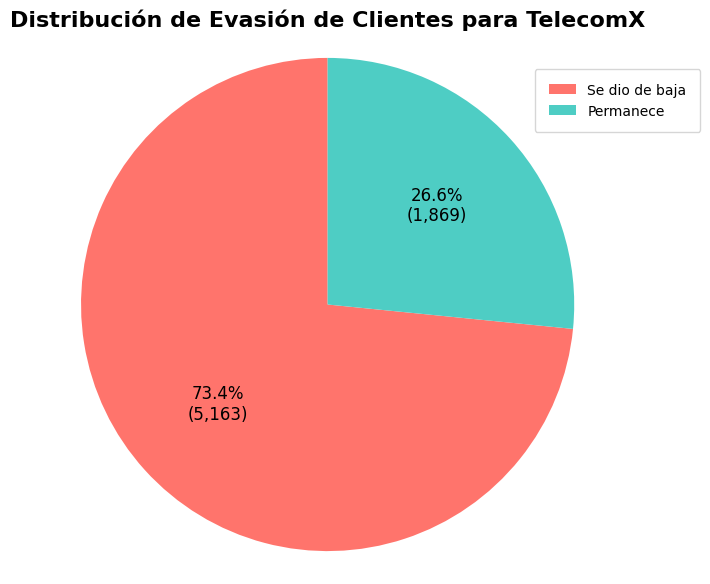

In [10]:
# Obtener el conteo de datos de la variable Churn
evasion = data['Churn'].value_counts()
total = sum(evasion.values)

# Cambiar a etiquetas más legibles para la leyenda
evasion.index = evasion.index.map({
    'Yes': 'Permanece',
    'No': 'Se dio de baja'
})

# Realizar el gráfico
plt.figure(figsize=(7, 7))
plt.pie( evasion.values,
         autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct * total / 100.0)):,})',
         textprops={'fontsize': 12},
         startangle=90,
         colors=['#FF746C', '#4ecdc4']
         )

# Modificar título y leyenda
plt.title( 'Distribución de Evasión de Clientes para TelecomX', fontsize=16, fontweight='bold' )
plt.axis('equal')
plt.legend( evasion.index,  loc='upper right', bbox_to_anchor=(1.20, 0.95), borderpad=1.0 )
plt.show()

# **Correlación y Selección de Variable**s

## Análisis de Correlación

In [11]:
import seaborn as sns
import numpy as np
import plotly.graph_objects as go

In [12]:
correlation = encoded_df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
correlation_masked = correlation.copy()
correlation_masked[mask] = np.nan

fig = go.Figure(data=go.Heatmap(
    z=correlation_masked.values,
    x=correlation_masked.columns,
    y=correlation_masked.index,
    colorscale='RdBu_r',
    zmid=0,
    colorbar=dict(title="Correlación"),
    hovertemplate='<b>%{y}</b> vs <b>%{x}</b><br>Correlación: <b>%{z:.3f}</b><extra></extra>'
))

fig.update_layout(
    title={
        'text': 'Mapa de Correlación de Variables',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18, 'weight': 'bold'}
    },
    width=1000,
    height=900,
    xaxis=dict(
        tickangle=-45,
        tickfont=dict(size=9)
    ),
    yaxis=dict(
        autorange='reversed',
        tickfont=dict(size=9)
    )
)

fig.show()

## Relación de variables respecto a la cancelación (Churn)

In [13]:
# Ordenar por correlación absoluta con Churn
sorted_cols = correlation['onehotencoder__Churn_Yes'].abs().sort_values(ascending=False).index.tolist()
corr_sorted = correlation.loc[sorted_cols, sorted_cols]

# Máscara triangular
mask = np.triu(np.ones_like(corr_sorted, dtype=bool))
corr_masked = corr_sorted.where(~mask)

# Texto anotaciones
text_vals = corr_masked.round(2).astype(str).replace('nan', '')

fig = go.Figure(go.Heatmap(
    z=corr_masked.values, x=corr_masked.columns, y=corr_masked.index,
    colorscale='RdBu_r', zmid=0, zmin=-1, zmax=1,
    colorbar=dict(title="Correlación"),
    hovertemplate='<b>%{y}</b> vs <b>%{x}</b><br>Correlación: <b>%{z:.3f}</b><extra></extra>'
))

churn_idx = sorted_cols.index('onehotencoder__Churn_Yes')
fig.add_shape(type='rect', line=dict(color='gold', width=2), fillcolor='rgba(0,0,0,0)',
              x0=-0.5, x1=churn_idx+0.5, y0=churn_idx-0.5, y1=churn_idx+0.5)

fig.update_layout(
   title={
        'text': 'Correlaciones respecto a Churn',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18, 'weight': 'bold'}
    },
    width=1100, height=1000,
    xaxis=dict(tickangle=-45, tickfont=dict(size=9)),
    yaxis=dict(autorange='reversed', tickfont=dict(size=9))
)

fig.show()

# **Modelado Predictivo**

## Separación de datos

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
y = encoded_df['onehotencoder__Churn_Yes']
X = encoded_df.drop(columns=['onehotencoder__Churn_Yes'])

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3, # 70/30
    stratify=y,
    random_state=42
)

## Selección de variables

In [25]:
import pandas as pd

# Feature importance con Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

top_10 = importances.head(10).index.tolist()
top_15 = importances.head(15).index.tolist()

print("TOP 10 VARIABLES:")
print(importances.head(10).to_string())
print("\nTOP 15 VARIABLES:")
print(importances.head(15).to_string())

TOP 10 VARIABLES:
onehotencoder__Contract_Mes a Mes              0.183410
remainder__tenure                              0.103201
onehotencoder__InternetService_Fibra Óptica    0.070167
remainder__Charges.Total                       0.069190
onehotencoder__TechSupport_Yes                 0.065176
onehotencoder__OnlineSecurity_Yes              0.060026
onehotencoder__PaperlessBilling_Yes            0.056956
onehotencoder__Partner_Yes                     0.038178
remainder__Charges.Monthly                     0.036707
onehotencoder__Dependents_Yes                  0.033212

TOP 15 VARIABLES:
onehotencoder__Contract_Mes a Mes                                   0.183410
remainder__tenure                                                   0.103201
onehotencoder__InternetService_Fibra Óptica                         0.070167
remainder__Charges.Total                                            0.069190
onehotencoder__TechSupport_Yes                                      0.065176
onehotencoder__Onl

## Balanceo de Clases (Oversampling)

In [26]:
from imblearn.over_sampling import SMOTE

In [27]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

## Creación de Modelos

### Regresión Logística

Normalización de datos

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

Tunning

In [46]:
from sklearn.linear_model import LogisticRegression

In [30]:
lr_params = {
    'C':       [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver':  ['saga']
}

scalers = {}

for name, features in [('10', top_10), ('15', top_15), ('all', X_train_sm.columns.tolist())]:
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_train_sm[features])
    scalers[name] = scaler                          # guardar para transformar X_test después

    lr_grid = GridSearchCV(
        LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42),
        lr_params, cv=5, scoring='f1', n_jobs=-1
    )
    lr_grid.fit(X_tr_scaled, y_train_sm)
    print(f"Mejores params LR ({name}):", lr_grid.best_params_)
    if   name == '10':  lr_10  = lr_grid.best_estimator_
    elif name == '15':  lr_15  = lr_grid.best_estimator_
    else:               lr_all = lr_grid.best_estimator_

# X_test escalado por cada scaler correspondiente
X_test_scaled_10  = scalers['10'].transform(X_test[top_10])
X_test_scaled_15  = scalers['15'].transform(X_test[top_15])
X_test_scaled_all = scalers['all'].transform(X_test)

Mejores params LR (10): {'C': 10, 'penalty': 'l1', 'solver': 'saga'}
Mejores params LR (15): {'C': 1, 'penalty': 'l1', 'solver': 'saga'}
Mejores params LR (all): {'C': 1, 'penalty': 'l1', 'solver': 'saga'}


### Random Forest

In [45]:
from sklearn.ensemble import RandomForestClassifier

Tunning

In [31]:
rf_params = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [5, 10, 15, None],
    'min_samples_leaf':[2, 5, 10],
    'max_features':    ['sqrt', 'log2']
}

for name, features in [('10', top_10), ('15', top_15), ('all', X_train_sm.columns.tolist())]:
    rf_grid = GridSearchCV(
        RandomForestClassifier(class_weight='balanced', random_state=42),
        rf_params, cv=5, scoring='f1', n_jobs=-1
    )
    rf_grid.fit(X_train_sm[features], y_train_sm)
    print(f"Mejores params RF ({name}):", rf_grid.best_params_)
    if   name == '10':  rf_10  = rf_grid.best_estimator_
    elif name == '15':  rf_15  = rf_grid.best_estimator_
    else:               rf_all = rf_grid.best_estimator_

Mejores params RF (10): {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}
Mejores params RF (15): {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 100}
Mejores params RF (all): {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 300}


## Evaluación de Modelos

**Función para evaluar modelos**

In [44]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

In [32]:
def evaluar_modelo(nombre, model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(f"{'═'*50}")
    print(f"{nombre}")
    print(f"{'═'*50}")
    print(f"Exactitud:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precisión:  {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:     {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score:   {f1_score(y_test, y_pred):.4f}")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap='Blues')
    plt.title(nombre)
    plt.show()

### Regresión Logística

Usando las mejores 10 variables

══════════════════════════════════════════════════
LR Top 10
══════════════════════════════════════════════════
Exactitud:  0.7270
Precisión:  0.4917
Recall:     0.7914
F1-Score:   0.6066


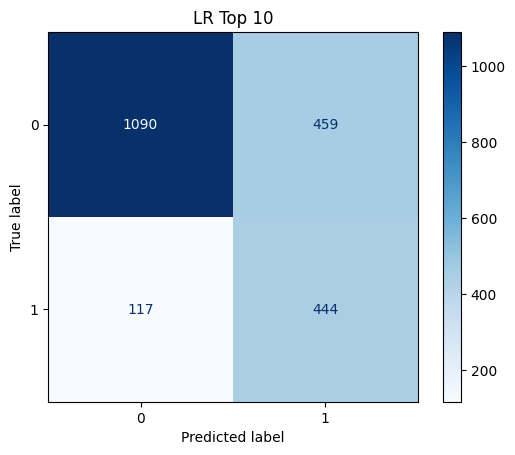

In [40]:
evaluar_modelo("LR Top 10", lr_10, X_test_scaled_10, y_test)

Usando las mejores 15 variables

══════════════════════════════════════════════════
LR Top 15
══════════════════════════════════════════════════
Exactitud:  0.7265
Precisión:  0.4912
Recall:     0.7932
F1-Score:   0.6067


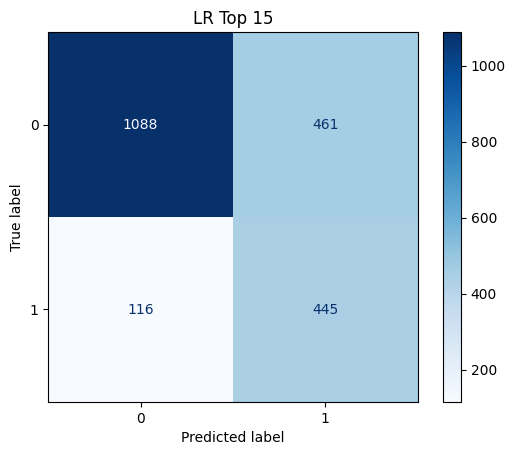

In [41]:
evaluar_modelo("LR Top 15", lr_15, X_test_scaled_15, y_test)

Usando todas las variables

══════════════════════════════════════════════════
LR All
══════════════════════════════════════════════════
Exactitud:  0.7464
Precisión:  0.5149
Recall:     0.8004
F1-Score:   0.6267


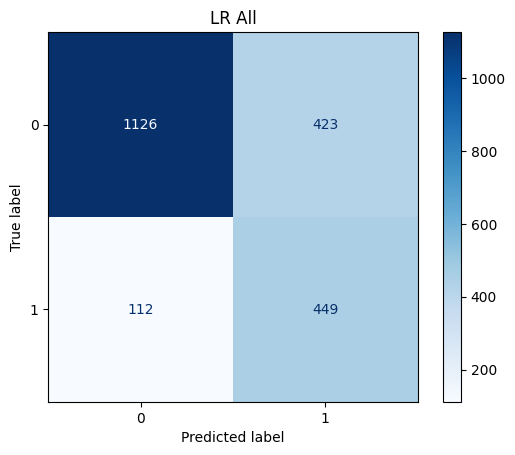

In [42]:
evaluar_modelo("LR All", lr_all, X_test_scaled_all, y_test)

### Random Forest

Top 10

══════════════════════════════════════════════════
Random Forest Top 10
══════════════════════════════════════════════════
Exactitud:  0.7787
Precisión:  0.5781
Recall:     0.6203
F1-Score:   0.5985


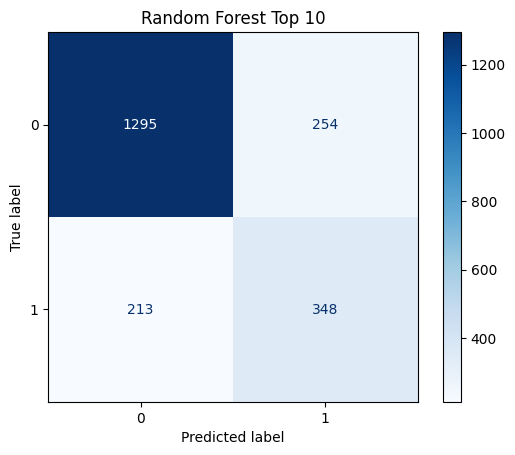

In [36]:
evaluar_modelo("Random Forest Top 10",  rf_10,  X_test[top_10], y_test)

Usando las mejores 15 variables

══════════════════════════════════════════════════
Random Forest Top 15
══════════════════════════════════════════════════
Exactitud:  0.7664
Precisión:  0.5548
Recall:     0.6132
F1-Score:   0.5826


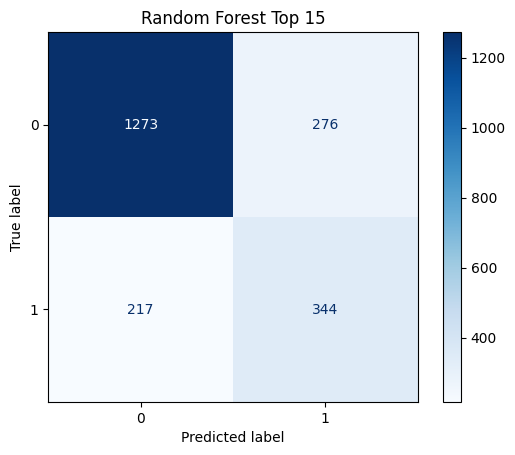

In [39]:
evaluar_modelo("Random Forest Top 15", rf_15, X_test[top_15], y_test)

Usando todas las variables

══════════════════════════════════════════════════
RANDOM FOREST All
══════════════════════════════════════════════════
Exactitud:  0.7735
Precisión:  0.5651
Recall:     0.6417
F1-Score:   0.6010


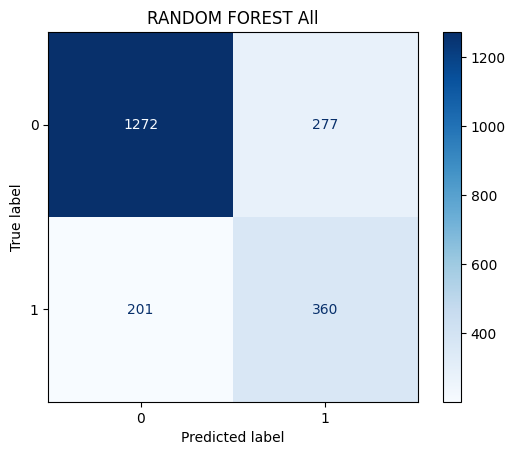

In [38]:
evaluar_modelo("RANDOM FOREST All", rf_all, X_test[X_train_sm.columns.tolist()], y_test)

## Comparación de Modelos